# 01 — Data Cleaning & Preprocessing
**Telco Customer Churn Analysis · Future Interns Task 2 · 2026**

---

## Objective
Before any analysis, the raw dataset must be inspected, cleaned, and structured. This notebook covers:
- Loading and profiling the raw data
- Identifying and resolving data quality issues
- Feature engineering for downstream analysis
- Exporting the clean dataset

> **Analysed:** The most important step in any data project is understanding *what the data actually contains* before trying to answer business questions with it.

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load the Raw Dataset

In [2]:
df = pd.read_csv('../dataset/raw/telco_customer_churn.csv')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")

Shape: 7,043 rows × 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
# First look at the data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Data Quality Assessment

Let's systematically check for issues: missing values, wrong data types, duplicates, and unexpected values.

In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing values per column:")
print(missing_report[missing_report['Missing Count'] > 0])

Missing values per column:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [6]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check unique customerIDs
unique_ids = df['customerID'].nunique()
print(f"Unique customerIDs: {unique_ids} (expected: {len(df)})")

Duplicate rows: 0
Unique customerIDs: 7043 (expected: 7043)


In [7]:
# Investigate TotalCharges — it's stored as object, not numeric
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("\nSample values with whitespace issue:")
print(df[df['TotalCharges'].str.strip() == '']['TotalCharges'].head(5))
print(f"\nRows with blank TotalCharges: {(df['TotalCharges'].str.strip() == '').sum()}")

TotalCharges dtype: str

Sample values with whitespace issue:
488      
753      
936      
1082     
1340     
Name: TotalCharges, dtype: str

Rows with blank TotalCharges: 11


## 3. Fixing Data Issues

**Issue found:** `TotalCharges` is stored as `object` (string) because 11 rows contain whitespace instead of a numeric value. These correspond to customers with `tenure = 0` — brand new customers who have not yet been billed.

**Decision:** Convert to numeric (whitespace → NaN), then drop these 11 rows. They represent 0.15% of data and carry no meaningful churn signal.

In [8]:
# Fix 1: Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Confirm the 11 null rows are tenure=0
print("Tenure for TotalCharges nulls:")
print(df[df['TotalCharges'].isnull()]['tenure'].value_counts())

# Drop those rows
df = df.dropna(subset=['TotalCharges'])
print(f"\nRows after dropping nulls: {len(df):,}")

Tenure for TotalCharges nulls:
tenure
0    11
Name: count, dtype: int64

Rows after dropping nulls: 7,032


## 4. Feature Engineering

Creating new features that make the analysis more meaningful.

In [9]:
# Binary churn column (Yes=1, No=0)
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
print(f"Churn rate: {df['Churn_bin'].mean()*100:.2f}%")

# Tenure cohort groups (for cohort analysis)
bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12m', '13-24m', '25-36m', '37-48m', '49-60m', '61-72m']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels)

# Customer Lifetime Value estimate
df['CLV'] = df['MonthlyCharges'] * df['tenure']

# Add-on count (number of extra services subscribed)
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df['addon_count'] = df[addon_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

print("\nNew columns added:")
print(df[['Churn_bin', 'tenure_group', 'CLV', 'addon_count']].head(5))

Churn rate: 26.58%

New columns added:
   Churn_bin tenure_group     CLV  addon_count
0          0        0-12m   29.85            1
1          0       25-36m 1936.30            2
2          1        0-12m  107.70            2
3          0       37-48m 1903.50            3
4          1        0-12m  141.40            0


In [10]:
# Drop customerID — not needed for analysis
df = df.drop(columns=['customerID'])
print(f"Final clean dataset shape: {df.shape}")
print(f"\nColumn list:")
print(df.columns.tolist())

Final clean dataset shape: (7032, 24)

Column list:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_bin', 'tenure_group', 'CLV', 'addon_count']


## 5. Final Data Profile

In [11]:
# Summary statistics for key numeric columns
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'CLV']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges,CLV
count,7032.00,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30,2283.15
std,24.55,30.09,2266.77,2264.70
min,1.00,18.25,18.80,18.80
25%,9.00,35.59,401.45,397.80
50%,29.00,70.35,1397.48,1394.57
75%,55.00,89.86,3794.74,3791.25
max,72.00,118.75,8684.80,8550.00


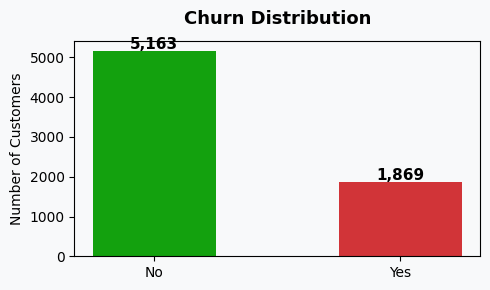


Retained: 5,163 (73.4%)
Churned:  1,869 (26.6%)


In [12]:
# Churn distribution
fig, ax = plt.subplots(figsize=(5, 3))
churn_counts = df['Churn'].value_counts()
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=['#13a10e', '#d13438'], edgecolor='none', width=0.5)
ax.set_title('Churn Distribution', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Number of Customers')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', fontsize=11, fontweight='bold')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('../reports/figures/00_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nRetained: {churn_counts['No']:,} ({churn_counts['No']/len(df)*100:.1f}%)")
print(f"Churned:  {churn_counts['Yes']:,} ({churn_counts['Yes']/len(df)*100:.1f}%)")

In [13]:
# Save clean dataset
os.mkdir("../dataset/cleaned")
df.to_csv('../dataset/cleaned/telco_churn_clean.csv', index=False)
print("Clean dataset saved to ../dataset/cleaned/telco_churn_clean.csv")
print(f"Final shape: {df.shape}")

Clean dataset saved to ../dataset/cleaned/telco_churn_clean.csv
Final shape: (7032, 24)


## Summary

| Step | Action | Result |
|---|---|---|
| Missing values | `TotalCharges` had 11 whitespace rows | Dropped (0.15% of data) |
| Type conversion | `TotalCharges` object → float | Fixed |
| Duplicates | Checked customerID uniqueness | None found |
| Feature engineering | `Churn_bin`, `tenure_group`, `CLV`, `addon_count` | Created |
| Dataset size | Final clean dataset | 7,032 rows × 22 columns |

**Next:** `02_exploratory_analysis.ipynb` — understanding who churns and why.